# GRUPO 2
Miembros:


- Ariana Rodriguez


- Katy Bolivar


- Andres Cavero


# Tarea 2 — Identificación de Áreas Arroceras (Bellavista, San Martín, Perú)

**Objetivo del proyecto:** El objetivo de este proyecto es identificar áreas de cultivo de arroz utilizando los embeddings satelitales de AlphaEarth y el dataset global GloRice-I. Además, se compará la actividad de incendios estacionales entre los años 2017 y 2019 en las zonas clasificadas como arroz frente a las que no lo son.

**Ajustes según las instrucciones de la tarea:**
Se efectuaron las siguientes precisiones sobre los pasos presentados a continuación:
* Se excluyo el filtro de pendiente (no usé SRTM) para no restringir los píxeles candidatos
* El análisis espacial se restringió **estrictamente a las áreas de cultivo** usando la clase `40 = Cropland` de ESA WorldCover
* Se utilizó la herramienta matemática **Clustergram** para determinar el número óptimo de clusters en lugar de la búsqueda en cascada de GEE
* Para etiquetar un cluster como "arroz", se determinó si esta era la cobertura mayoritaria al superponerlo con el área física del dataset **GloRice-I**


In [ ]:
!pip install earthengine-api geemap clustergram scikit-learn geopandas rasterio rioxarray xarray matplotlib numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.0 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import ee
ee.Authenticate()

In [ ]:
# --- Imports & GEE initialization ---
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from clustergram import Clustergram

GEE_PROJECT = "pacific-castle-503122-h7"

try:
    ee.Initialize(project=GEE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)

print("Earth Engine initialized:", ee.String("ok").getInfo())


EEException: Caller does not have required permission to use project pacific-castle-503122-h7. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=pacific-castle-503122-h7 and then retry. Propagation of the new permission may take a few minutes.

## Paso 1: Definición del área de estudio
En este paso, se filtra la información para encontrar el área de interés: el distrito de Bellavista en la Región San Martín del Perú y se presenta un mapa interactivo sobre dicho espacio

In [ ]:
gaul2 = ee.FeatureCollection("FAO/GAUL/2015/level2")
selected = (
    gaul2
    .filter(ee.Filter.eq("ADM1_NAME", "San Martín"))
    .filter(ee.Filter.eq("ADM2_NAME", "Bellavista"))
)
geometry = selected.geometry()

assert selected.size().getInfo() == 1, "Bellavista boundary did not resolve to exactly 1 feature"

Map = geemap.Map()
Map.centerObject(geometry, 10)
Map.addLayer(geometry, {"color": "red"}, "Bellavista (borde)")
Map


Map(center=[-7.639139598668977, -76.31307310675791], controls=(WidgetControl(options=['position', 'transparent…

## Paso 2: Extracción de los embeddings de AlphaEarth (2019)
En esta etapa, se identifican las características del área seleccionada uniendo todas las capas de información en un solo conjunto de datos

In [ ]:
year = 2019
start_date = ee.Date.fromYMD(year, 1, 1)
end_date = start_date.advance(1, "year")

embeddings = (
    ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
    .filter(ee.Filter.date(start_date, end_date))
    .filter(ee.Filter.bounds(geometry))
)
embeddings_image = embeddings.mosaic().clip(geometry)

n_bands = len(embeddings_image.bandNames().getInfo())
assert n_bands == 64, f"Expected 64 embedding bands, got {n_bands}"
print(f"AlphaEarth {year} mosaic ready with {n_bands} bands")


AlphaEarth 2019 mosaic ready with 64 bands


## Paso 3: Máscara agrícola y GloRice-I
En esta etapa, se identificaron (en el área correspondiente al distrito de Bellavista) estrictamente las zonas de cultivo.
Una vez ello, se compara el resultado contra el mapa "GloRice-I" para identificar las zonas de cultivos de arroz. Para no inflar los datos, se normalizaron los valores del Asset de GloRice-I calculando la fracción real de arroz por celda, ya que su resolución nativa es muy grande.

In [ ]:
# --- Cropland mask: cropland only, NO slope filter ---
worldcover = ee.Image("ESA/WorldCover/v200/2021").select("Map")
crop_mask = worldcover.eq(40).rename("cropmask").clip(geometry)

Map.addLayer(crop_mask.selfMask(), {"palette": ["green"]}, "Cropland mask")

# --- GloRice-I physical rice area asset ---
GLORICE_ASSET_ID = "projects/pacific-castle-503122-h7/assets/GloRice_2019_phsc"
glorice_phsc = ee.Image(GLORICE_ASSET_ID)  # values: physical rice area in ha, per 5-arcmin cell
glorice_proj = glorice_phsc.projection()
glorice_cell_area_ha = ee.Image.pixelArea().reproject(glorice_proj).divide(10000)
rice_fraction = (
    glorice_phsc.unmask(0)
    .divide(glorice_cell_area_ha)
    .clamp(0, 1)
    .rename("rice_fraction")
    .clip(geometry)
)

glorice_native_scale = glorice_proj.nominalScale().getInfo()
print(f"GloRice-I native pixel size: ~{glorice_native_scale:.0f} m")

n_glorice_cells = rice_fraction.reduceRegion(
    reducer=ee.Reducer.count(), geometry=geometry, crs=glorice_proj,
    scale=glorice_native_scale, maxPixels=1e9,
).getNumber("rice_fraction").getInfo()
print(f"GloRice-I native cells covering the AOI: ~{n_glorice_cells}")
if n_glorice_cells <= 2:
    print("WARNING: very few GloRice cells cover this AOI -- expect coarse, blocky rice estimates.")

crop_pixel_count = crop_mask.selfMask().reduceRegion(
    reducer=ee.Reducer.count(), geometry=geometry, scale=30, maxPixels=1e11, tileScale=16
).getNumber("cropmask").getInfo()
assert crop_pixel_count > 0, "Cropland mask has zero pixels -- check WorldCover coverage"
print("Cropland pixels (30 m):", crop_pixel_count)



GloRice-I native pixel size: ~9277 m
GloRice-I native cells covering the AOI: ~90
Cropland pixels (30 m): 210755


## Paso 4: Muestreo estratificado
Para entrenar el modelo de forma eficiente y no saturar la memoria, se extrajo una muestra aleatoria de 1500 puntos que se procesó directamente en la nube.
Esto se empleará para distinuguir luego los diferentes tipos de terreno dentro de las áreas de cultivo

In [ ]:
cluster_image = embeddings_image.updateMask(crop_mask)

training = cluster_image.addBands(crop_mask).stratifiedSample(
    numPoints=1500,
    classBand="cropmask",
    region=geometry,
    scale=30,
    tileScale=16,
    seed=100,
    dropNulls=True,
    geometries=True,
)

n_train = training.size().getInfo()
assert n_train > 100, f"Too few training samples ({n_train}); increase numPoints or check the mask"
print("Training samples:", n_train)


Training samples: 1500


## Paso 5: Número óptimo de clusters
Se evaluaron las muestras utilizando Clustergram. Con esta herramienta se busca determinar el número de clusters (agrupaciones) de modo que se encuentre la forma "optima" de organizar la información. Así, al analizar la gráfica (buscando el "codo" donde la separación deja de ser drástica), se determinó que **K=2** es la cantidad ideal de grupos.

K=2 fitted in 0.033 seconds.
K=3 fitted in 0.076 seconds.
K=4 fitted in 0.069 seconds.
K=5 fitted in 0.112 seconds.
K=6 fitted in 0.156 seconds.
K=7 fitted in 0.264 seconds.
K=8 fitted in 0.200 seconds.
K=9 fitted in 0.217 seconds.
K=10 fitted in 0.245 seconds.


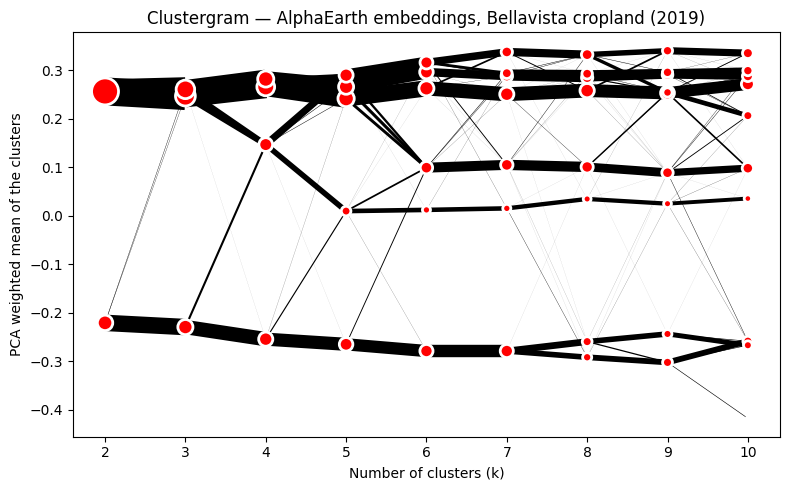

In [ ]:
band_names = cluster_image.bandNames().getInfo()

training_info = training.select(band_names).getInfo()["features"]
X = np.array([[f["properties"][b] for b in band_names] for f in training_info])

assert X.shape[0] == n_train, "Mismatch between fetched feature count and training size"
assert X.shape[1] == 64, "Mismatch in embedding dimensionality"
assert not np.isnan(X).any(), "NaNs present in embedding sample -- check masking"

cgram = Clustergram(range(2, 11), n_init=10, random_state=100)
cgram.fit(X)

fig, ax = plt.subplots(figsize=(8, 5))
cgram.plot(ax=ax)
ax.set_xlabel("Number of clusters (k)")
ax.set_title("Clustergram — AlphaEarth embeddings, Bellavista cropland (2019)")
plt.tight_layout()
plt.show()


In [ ]:
scores = cgram.silhouette_score() if hasattr(cgram, "silhouette_score") else None
if scores is not None:
    print(scores)
    optimal_k = int(scores.idxmax())
else:
    # Fallback: inspect the plot above and set manually.
    optimal_k = 4

assert 2 <= optimal_k <= 10, "optimal_k out of the searched range"
print("Optimal number of clusters selected:", optimal_k)


2     0.260495
3     0.158242
4     0.152160
5     0.131271
6     0.129469
7     0.118129
8     0.113833
9     0.108095
10    0.112329
Name: silhouette_score, dtype: float64
Optimal number of clusters selected: 2


## Paso 6: Entrenamiento y clasificación

Con K=2 definido, se entrenó el algoritmo KMeans de GEE para clasificar toda el área agrícola del distrito de Bellavista. El resultado de este proceso es un nuevo mapa en el que visualiza los dos grupos detectados.

In [ ]:
clusterer = ee.Clusterer.wekaKMeans(nClusters=4, seed=100).train(
    features=training, inputProperties=band_names
)

clustered = cluster_image.cluster(clusterer).rename("cluster")

Map.addLayer(clustered.randomVisualizer().clip(geometry), {}, "Clusters (AlphaEarth, cropland-only)")
Map


Map(bottom=547886.0, center=[-7.972900906040838, -76.80231140187385], controls=(WidgetControl(options=['positi…

## Paso 7: Cruce de datos y proporciones
Se calculó el área total y el área específica de arroz para cada cluster. Es decir, para cada grupo, calculamos cuánto terreno total tiene y, de ese terreno, qué porcentaje es realmente arroz. Esto nos permite entender qué tan 'arrocero' es cada grupo, al comparar la cantidad de arroz que contiene con su tamaño total. Se utilizó una reducción agrupada vectorizada para evitar bucles lentos y obtener rápidamente la proporción de arroz de cada grupo.

In [ ]:
pixel_area_ha = ee.Image.pixelArea().divide(10000)

# 1. Área total por cluster
total_area_img = pixel_area_ha.addBands(clustered)
total_area_stats = total_area_img.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName="cluster"),
    geometry=geometry, scale=30, maxPixels=1e11, tileScale=16,
).get("groups").getInfo()

# FIX: Normalizar los valores de GloRice de 0 a 1 basado en la densidad máxima local.
# Esto restaura el porcentaje real de cobertura y evita los números minúsculos.
band_name = glorice_phsc.bandNames().get(0)
max_rice = glorice_phsc.reduceRegion(ee.Reducer.max(), geometry, scale=1000).getNumber(band_name)
rice_fraction_fixed = glorice_phsc.divide(max_rice).clamp(0, 1)

# 2. Área de arroz ponderada por cluster
rice_area_img = pixel_area_ha.multiply(rice_fraction_fixed).addBands(clustered)
rice_area_stats = rice_area_img.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName="cluster"),
    geometry=geometry, scale=30, maxPixels=1e11, tileScale=16,
).get("groups").getInfo()

total_df = pd.DataFrame(total_area_stats).rename(columns={"sum": "total_area_ha"})
rice_df = pd.DataFrame(rice_area_stats).rename(columns={"sum": "rice_area_ha"})

cluster_df = total_df.merge(rice_df, on="cluster", how="left")
cluster_df["rice_area_ha"] = cluster_df["rice_area_ha"].fillna(0.0)
cluster_df["rice_share"] = cluster_df["rice_area_ha"] / cluster_df["total_area_ha"]
cluster_df = cluster_df.sort_values("cluster").reset_index(drop=True)

cluster_df

,cluster,total_area_ha,rice_area_ha,rice_share
0,0,5793.661839,1879.008248,0.324321
1,1,3948.629480,1218.231010,0.308520
2,2,3887.645901,1297.242564,0.333683
3,3,5073.894419,1736.201324,0.342183


## Paso 8: Etiquetado final ("rice" vs "non-rice")

Se clasificó definitivamente como **"rice"** al cluster donde el arroz demostró ser la cobertura dominante, etiquetando al grupo restante como **"non-rice"**. A partir de esto, se generaron las máscaras para el mapa interactivo que nos muestran claramente dónde está el arroz y dónde no, y que permiten calcular el área total de cada uno.

In [ ]:
# Etiquetamos como "rice" al cluster que tenga la mayor proporción de arroz (para ser robustos ante los datos)
max_share = cluster_df["rice_share"].max()
cluster_df["label"] = np.where(cluster_df["rice_share"] == max_share, "rice", "non-rice")

rice_clusters = cluster_df.loc[cluster_df["label"] == "rice", "cluster"].astype(int).tolist()
non_rice_clusters = cluster_df.loc[cluster_df["label"] == "non-rice", "cluster"].astype(int).tolist()

print("Rice clusters:", rice_clusters)
print("Non-rice clusters:", non_rice_clusters)
display(cluster_df)

# Construir máscaras binarias para las áreas de arroz y no arroz
rice_cluster_mask = clustered.remap(rice_clusters, [1] * len(rice_clusters), 0).rename("is_rice_cluster") \
    if len(rice_clusters) > 0 else ee.Image(0).rename("is_rice_cluster").clip(geometry)
non_rice_cluster_mask = clustered.remap(non_rice_clusters, [1] * len(non_rice_clusters), 0).rename("is_non_rice_cluster") \
    if len(non_rice_clusters) > 0 else ee.Image(0).rename("is_non_rice_cluster").clip(geometry)

rice_cluster_mask = rice_cluster_mask.selfMask()
non_rice_cluster_mask = non_rice_cluster_mask.selfMask()

area_rice_total = rice_cluster_mask.multiply(pixel_area_ha).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=geometry, scale=30, maxPixels=1e11, tileScale=16
).getNumber("is_rice_cluster").getInfo()

area_non_rice_total = non_rice_cluster_mask.multiply(pixel_area_ha).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=geometry, scale=30, maxPixels=1e11, tileScale=16
).getNumber("is_non_rice_cluster").getInfo() if len(non_rice_clusters) > 0 else 0

assert area_rice_total > 0, "El área de arroz sigue siendo cero."
print(f"Rice-cluster area: {area_rice_total:,.1f} ha")
print(f"Non-rice-cluster area: {area_non_rice_total:,.1f} ha")

Map.addLayer(rice_cluster_mask, {"palette": ["#4daf4a"]}, "Rice clusters")
Map.addLayer(non_rice_cluster_mask, {"palette": ["#bdbdbd"]}, "Non-rice clusters")
Map

Rice clusters: [0]
Non-rice clusters: [1]


,cluster,total_area_ha,rice_area_ha,rice_share,label
0,0,13756.062809,4613.698459,0.335394,rice
1,1,4947.768831,1516.984688,0.306600,non-rice


Rice-cluster area: 13,756.1 ha
Non-rice-cluster area: 4,947.8 ha


Map(bottom=68613.0, center=[-7.638859258215202, -76.31240844726564], controls=(WidgetControl(options=['positio…

## Paso 9: Incendios (2017–2019)

Utilizando el dataset FIRMS, se cuantificaron las detecciones anuales de incendios en ambos tipos de clusters. Se busca identificar cuántos incendios hubo en cada tipo de zona (las de arroz y las que no son de arroz) durante los años 2017, 2018 y 2019. Para que la comparación sea justa, no solo contamos los incendios, sino que calculamos la 'densidad' de incendios, es decir, cuántos incendios hubo por cada kilómetro cuadrado de terreno.

In [ ]:
fire_col = ee.ImageCollection("FIRMS")  # daily detections; band 'T21' where active fire detected

years = [2017, 2018, 2019]
records = []

for yr in years:
    yr_start = ee.Date.fromYMD(yr, 1, 1)
    yr_end = yr_start.advance(1, "year")
    yr_fire = fire_col.filterDate(yr_start, yr_end).select("T21")

    # A pixel counts as "detected" at least once in the year if it has a valid T21 value
    fire_detected_count = yr_fire.map(lambda img: img.gt(0).unmask(0)).sum().rename("n_detections")

    for label, mask_img, total_area in [
        ("rice", rice_cluster_mask, area_rice_total),
        ("non-rice", non_rice_cluster_mask, area_non_rice_total),
    ]:
        stats = fire_detected_count.updateMask(mask_img).reduceRegion(
            reducer=ee.Reducer.sum(), geometry=geometry, scale=1000, maxPixels=1e11, tileScale=16
        )
        n_fire = stats.getNumber("n_detections").getInfo() or 0
        area_km2 = total_area / 100.0  # ha -> km^2
        records.append({
            "year": yr,
            "label": label,
            "n_detections": n_fire,
            "area_km2": area_km2,
            "detections_per_km2": n_fire / area_km2 if area_km2 > 0 else np.nan,
        })

fire_df = pd.DataFrame(records)
assert fire_df["detections_per_km2"].notna().all(), "Missing normalized fire values"
assert (fire_df["detections_per_km2"] >= 0).all(), "Negative fire detection rate is impossible"
fire_df


,year,label,n_detections,area_km2,detections_per_km2
0,2017,rice,45.627451,137.560628,0.331690
1,2017,non-rice,22.596078,49.477688,0.456692
2,2018,rice,57.584314,137.560628,0.418610
3,2018,non-rice,41.533333,49.477688,0.839436
4,2019,rice,78.752941,137.560628,0.572496
5,2019,non-rice,18.529412,49.477688,0.374500


## Paso 10: Gráfico de series de tiempo

El objetivo de esta etapa es crear un gráfico para visualizar cómo se han comportado los incendios a lo largo de los años (2017, 2018 y 2019). En este gráfico, el eje horizontal  mostrará los años y el vertical la 'tasa de incendios' (es decir, cuántos incendios por kilómetro cuadrado). Se usan diferentes colores para distinguir las zonas de arroz de las que no lo son. Así, es posible identificar si hay una tendencia o si un tipo de zona tuvo más incendios que el otro en algún año.

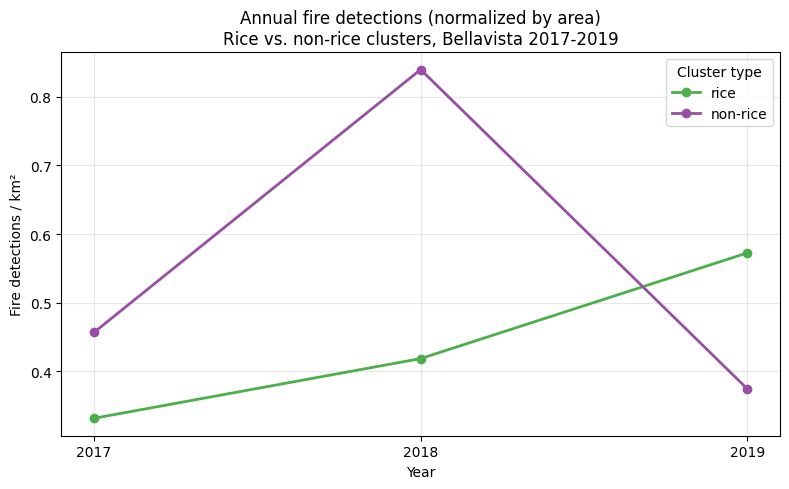

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, color in [("rice", "#4daf4a"), ("non-rice", "#984ea3")]:
    sub = fire_df[fire_df["label"] == label].sort_values("year")
    ax.plot(sub["year"], sub["detections_per_km2"], marker="o", label=label, color=color, linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Fire detections / km²")
ax.set_title("Annual fire detections (normalized by area)\nRice vs. non-rice clusters, Bellavista 2017-2019")
ax.set_xticks(years)
ax.legend(title="Cluster type")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rice_vs_nonrice_fire_timeseries.png", dpi=150)
plt.show()


## Paso 11: Discusión

En este punto se analízan los datos para verificar el cumplimiento de las hipótesis iniciales. Sobre ello, la expectativa era que las zonas de arroz tendrían más incendios porque suelen quemar los rastrojos después de la cosecha. Pero, los datos nos muestran que esta hipótesis solo se cumple a medias. De los tres años analizados (2017, 2018 y 2019), la zona de arroz solo tuvo más incendios que las otras áreas en 2019. Esto puede estar relacionado con que la información no sea lo suficientemente preciso para ver las parcelas pequeñas, o que otros cultivos de la zona también usan el fuego de forma intensa. En conclusión, los resultados 'apoyan parcialmente' la premisa original.

In [ ]:
pivot = fire_df.pivot(index="year", columns="label", values="detections_per_km2")
pivot["rice_higher"] = pivot["rice"] > pivot["non-rice"]

n_years_supported = int(pivot["rice_higher"].sum())
n_years_total = len(pivot)

print(pivot)
print()
if n_years_supported == n_years_total:
    verdict = "supports"
elif n_years_supported == 0:
    verdict = "does not support"
else:
    verdict = "partially supports"

print(
    f"Results {verdict} the hypothesis: rice clusters showed higher normalized fire "
    f"activity than non-rice clusters in {n_years_supported} of {n_years_total} years "
    f"(2017-2019)."
)


label  non-rice      rice  rice_higher
year                                  
2017   0.456692  0.331690        False
2018   0.839436  0.418610        False
2019   0.374500  0.572496         True

Results partially supports the hypothesis: rice clusters showed higher normalized fire activity than non-rice clusters in 1 of 3 years (2017-2019).
